In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [2]:
# Load the data.
mnist_train = pd.read_csv('mnist_train.csv')
mnist_test = pd.read_csv('mnist_test.csv')

# Visualise the first 5 rows.
mnist_train.head(5)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Extract the predictors and true labels.
X_train = mnist_train.drop(columns=['label'])
y_train = pd.get_dummies(mnist_train['label'])
y_train.head(5)

,0,1,2,3,4,5,6,7,8,9
0,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,1,0
4,0,0,1,0,0,0,0,0,0,0


In [4]:
# Convert the data to numpy arrays.
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

# Normalize the data.
X_train = X_train / 255.0

# Print the shapes of the arrays.
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (6000, 784)
y_train shape: (6000, 10)


In [5]:
# Extract the predictors and true labels.
X_test = mnist_test.drop(columns=['label'])
y_test = pd.get_dummies(mnist_test['label'])
y_test.head(5)

,0,1,2,3,4,5,6,7,8,9
0,1,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0
2,0,0,0,1,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0


In [6]:
# Convert the data to numpy arrays.
X_test = X_test.to_numpy()
y_test = y_test.to_numpy()

# Normalize the data.
X_test = X_test / 255.0

# Print the shapes of the arrays.
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (1000, 784)
y_test shape: (1000, 10)


## Task 1

#### 1.1.1

In [7]:
lr_range = np.logspace(-5, -1, base=10, num=7)  # learning range
batch_size = 128  # batch size
num_epochs = 40  # number of epochs

In [8]:
# Load the data into tf.data.Dataset objects.
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

# Batch the data.
train_dataset = train_dataset.batch(batch_size)
test_dataset = test_dataset.batch(batch_size)

losses=[]
for lr in lr_range:
    # Create the model.
    mlp_model = Sequential(
        [
            Dense(200, activation='softplus'),
            Dense(200, activation='softplus'),
            Dense(200, activation='softplus'),
            Dense(10, activation='softmax')
        ],
        name='task1-1-1'
    )

    # Compile the model.
    mlp_model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
        loss=tf.keras.losses.KLDivergence(),
        metrics=['accuracy']
    )

    # Train the model.
    mlp_model.fit(
        train_dataset,
        epochs=num_epochs,
        validation_data=test_dataset,
        verbose=0
    )

    # Evaluate the model.
    loss, accuracy = mlp_model.evaluate(test_dataset, verbose=0)
    losses.append(loss)

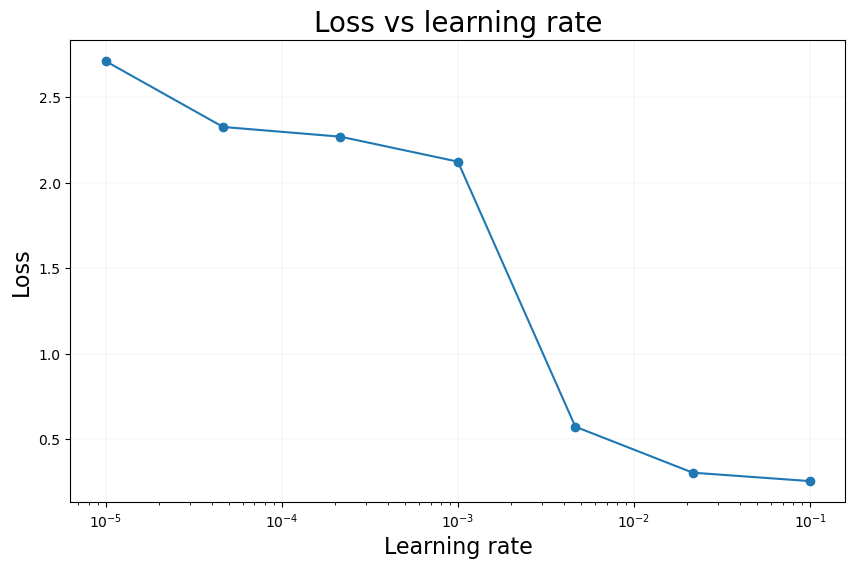

In [9]:
# Plot the loss vs learning rate.
plt.figure(figsize=(10, 6))

# Set the grid.
plt.grid(visible=True, linewidth=0.1)

# Label the plot.
plt.title('Loss vs learning rate', fontsize=20)
plt.xlabel('Learning rate', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Plot the loss vs learning rate.
plt.xscale("log")
plt.plot(lr_range, losses, marker='o')

# Show the plot.
plt.show()